# GigShield ML Pipeline
## AI-Powered Parametric Insurance for India's Gig Economy

### Models Built:
1. Risk Profiling — Random Forest (Zone Risk Score 0-100)
2. Dynamic Premium — Linear Regression + Random Forest
3. Disruption Prediction — XGBoost Classifier
4. Fraud Detection — Isolation Forest (Spoofing Risk Score)
5. Dynamic Risk Map — K-Means Clustering
6. Behavioral Ring Detection — DBSCAN

### Stack: Python, Scikit-learn, XGBoost, Pandas, NumPy

In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt 
import joblib
np.random.seed(42)  # reproducibility
N = 1000            # 1000 zones

df = pd.DataFrame({
    'avg_rainfall_mm'        : np.random.uniform(200, 1500, N),   # mm/year
    'flood_incidents_per_year': np.random.randint(0, 15, N),
    'avg_aqi'                : np.random.uniform(50, 400, N),
    'curfew_days_per_year'   : np.random.randint(0, 10, N),
    'hub_closure_days'       : np.random.randint(0, 20, N),
    'avg_temp_peak_celsius'  : np.random.uniform(28, 48, N),
    'worker_density'         : np.random.randint(50, 500, N),
    'zone_type'              : np.random.choice([0, 1, 2], N)
    # 0=residential, 1=commercial, 2=industrial
})
# ── 2. PROGRAMMATIC LABELING ───────────────────────────────────────────────────
# Normalize each feature to 0-100, then apply business weights

def normalize(series, low, high):
    return ((series - low) / (high - low) * 100).clip(0, 100)

rainfall_score    = normalize(df['avg_rainfall_mm'], 200, 1500)
flood_score       = normalize(df['flood_incidents_per_year'], 0, 15)
aqi_score         = normalize(df['avg_aqi'], 50, 400)
curfew_score      = normalize(df['curfew_days_per_year'], 0, 10)
hub_score         = normalize(df['hub_closure_days'], 0, 20)
temp_score        = normalize(df['avg_temp_peak_celsius'], 28, 48)
# Weighted formula — you define this as domain expert
df['risk_score'] = (
    0.30 * rainfall_score +
    0.25 * flood_score    +
    0.20 * aqi_score      +
    0.15 * curfew_score   +
    0.05 * hub_score      +
    0.05 * temp_score
).round(2)

print(df[['avg_rainfall_mm', 'flood_incidents_per_year', 'risk_score']].head(10))
print("\nRisk Score Stats:\n", df['risk_score'].describe())

   avg_rainfall_mm  flood_incidents_per_year  risk_score
0       686.902155                        14       54.94
1      1435.928598                        11       61.66
2      1151.592124                        13       73.74
3       978.256029                         7       44.77
4       402.824233                         2       45.70
5       402.792876                         7       43.15
6       275.508696                        14       46.28
7      1326.028990                         4       43.68
8       981.449515                         0       38.00
9      1120.494351                         6       56.76

Risk Score Stats:
 count    1000.000000
mean       48.220960
std        13.674553
min         7.550000
25%        38.482500
50%        46.915000
75%        58.447500
max        84.020000
Name: risk_score, dtype: float64


In [10]:
X = df.drop('risk_score',axis=1) #input features
Y = df['risk_score'] #target

X_train , X_test , Y_train , Y_test = train_test_split(
    X , Y ,test_size=0.2 , random_state = 42 )
print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")

model = RandomForestRegressor(
    n_estimators=100,    # 100 trees
    max_depth=10,        # prevent overfitting
    min_samples_leaf=5,  # each leaf needs at least 5 samples
    random_state=42
)
model.fit(X_train,Y_train)
print("\n Model trained successfully")
Y_pred = model.predict(X_test)
mae = mean_absolute_error(Y_test,Y_pred)
r2 = r2_score(Y_test,Y_pred)
print(f"\nMAE  : {mae:.2f}  (avg error in risk score points)")
print(f"R²   : {r2:.4f}  (1.0 = perfect, >0.85 is good)")


Training samples: 800, Test samples: 200

 Model trained successfully

MAE  : 2.76  (avg error in risk score points)
R²   : 0.9380  (1.0 = perfect, >0.85 is good)



Feature Importances:
 avg_rainfall_mm             0.476397
flood_incidents_per_year    0.262238
avg_aqi                     0.171400
curfew_days_per_year        0.076541
avg_temp_peak_celsius       0.005022
hub_closure_days            0.004707
worker_density              0.003021
zone_type                   0.000674
dtype: float64


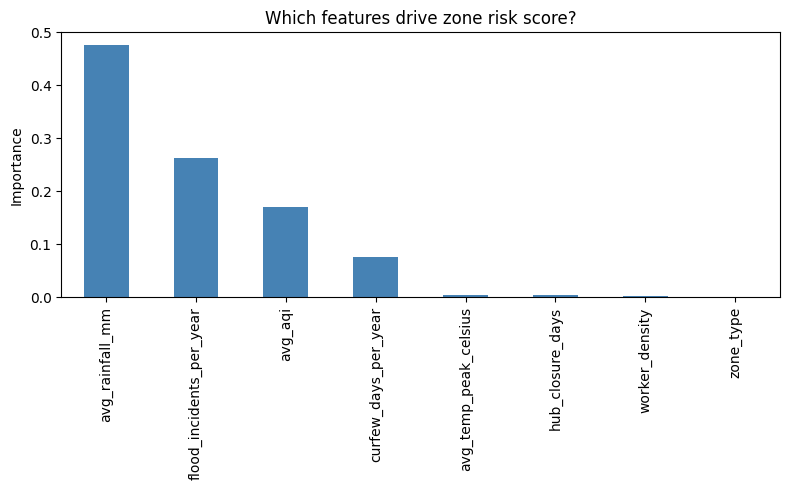


Model saved as risk_profiling_model.pkl

Predicted Risk Score for new zone: 52.7 / 100


In [11]:
# ── 7. FEATURE IMPORTANCE ──────────────────────────────────────────────────────

importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importances:\n", importances)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('Which features drive zone risk score?')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# ── 8. SAVE MODEL ──────────────────────────────────────────────────────────────

joblib.dump(model, 'risk_profiling_model.pkl')
print("\nModel saved as risk_profiling_model.pkl")

# ── 9. TEST ON A NEW ZONE ──────────────────────────────────────────────────────

new_zone = pd.DataFrame([{
    'avg_rainfall_mm'        : 1200,  # high rainfall — Koramangala-like
    'flood_incidents_per_year': 8,
    'avg_aqi'                : 180,
    'curfew_days_per_year'   : 2,
    'hub_closure_days'       : 5,
    'avg_temp_peak_celsius'  : 38,
    'worker_density'         : 300,
    'zone_type'              : 1
}])

predicted_risk = model.predict(new_zone)[0]
print(f"\nPredicted Risk Score for new zone: {predicted_risk:.1f} / 100")

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(Y_test, Y_pred)
mse  = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(Y_test, Y_pred)

print(f"MAE  : {mae:.2f}  → avg error in risk score points")
print(f"MSE  : {mse:.2f}  → penalizes large errors")
print(f"RMSE : {rmse:.2f} → same units as MAE, outlier-sensitive")
print(f"R²   : {r2:.4f}  → % of variance explained")

MAE  : 2.76  → avg error in risk score points
MSE  : 12.47  → penalizes large errors
RMSE : 3.53 → same units as MAE, outlier-sensitive
R²   : 0.9380  → % of variance explained


In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

np.random.seed(42)
N = 1000

# ── 1. SYNTHETIC DATA GENERATION ──────────────────────────────────────────────

df = pd.DataFrame({
    'zone_risk_score'        : np.random.uniform(10, 90, N),
    'season'                 : np.random.choice([0, 1, 2], N),
    # 0=summer, 1=monsoon, 2=winter
    'weeks_claim_free'       : np.random.randint(0, 52, N),
    'worker_platform'        : np.random.choice([0, 1], N),
    'zone_type'              : np.random.choice([0, 1, 2], N),
    'next_week_rain_forecast': np.random.uniform(0, 200, N),
    'next_week_aqi_forecast' : np.random.uniform(50, 350, N),
})

# ── 2. PROGRAMMATIC LABELING ───────────────────────────────────────────────────
# Mirror GigShield's pricing formula exactly

base_premium     = 70

zone_modifier    = (df['zone_risk_score'] / 100) * 15
# Rs.0 to Rs.15 based on risk

seasonal_mod     = df['season'].map({0: 0, 1: 8, 2: 2})
# monsoon adds Rs.8, winter Rs.2

loyalty_discount = (df['weeks_claim_free'] / 52) * 10
# up to Rs.10 discount for claim-free year

rain_modifier    = (df['next_week_rain_forecast'] / 200) * 5
# up to Rs.5 extra if heavy rain forecast

aqi_modifier     = np.where(df['next_week_aqi_forecast'] > 200, 3, 0)
# flat Rs.3 if AQI forecast is bad

df['weekly_premium_rs'] = (
    base_premium
    + zone_modifier
    + seasonal_mod
    - loyalty_discount
    + rain_modifier
    + aqi_modifier
).clip(60, 100).round(2)
# clip ensures premium stays in Rs.60-100 range

print(df[['zone_risk_score', 'season', 'weeks_claim_free',
          'weekly_premium_rs']].head(10))
print("\nPremium Stats:\n", df['weekly_premium_rs'].describe())

   zone_risk_score  season  weeks_claim_free  weekly_premium_rs
0        39.963210       2                21              75.01
1        86.057145       1                36              88.96
2        68.559515       2                51              77.38
3        57.892679       2                41              79.05
4        22.481491       0                11              75.28
5        22.479562       0                46              71.10
6        14.646689       2                48              67.93
7        79.294092       0                41              77.28
8        58.089201       1                37              81.87
9        66.645806       1                17              91.10

Premium Stats:
 count    1000.000000
mean       79.781090
std         5.810174
min        65.100000
25%        75.605000
50%        79.540000
75%        83.682500
max        97.530000
Name: weekly_premium_rs, dtype: float64


In [27]:
X = df.drop('weekly_premium_rs',axis=1)
Y = df['weekly_premium_rs']
X_train , X_test , Y_train, Y_test = train_test_split(
    X,Y , test_size = 0.2 , random_state = 42)
#Model A
lr = LinearRegression()
lr.fit(X_train,Y_train)
Y_pred_lr = lr.predict(X_test) 
# Model B
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train,Y_train)
Y_pred_rf = rf.predict(X_test)

def evaluate(name, Y_test, Y_pred):
    mae  = mean_absolute_error(Y_test, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    r2   = r2_score(Y_test, Y_pred)
    print(f"\n{name}")
    print(f"  MAE  : {mae:.2f} Rs.")
    print(f"  RMSE : {rmse:.2f} Rs.")
    print(f"  R²   : {r2:.4f}")

evaluate("Linear Regression", Y_test, Y_pred_lr)
evaluate("Random Forest",     Y_test, Y_pred_rf)

# ── 5. LINEAR REGRESSION COEFFICIENTS ─────────────────────────────────────────
# This shows exactly how each feature affects premium — good for explainability

coeff_df = pd.DataFrame({
    'feature'    : X.columns,
    'coefficient': lr.coef_
}).sort_values('coefficient', ascending=False)

print("\nLinear Regression Coefficients:")
print(coeff_df.to_string(index=False))
print(f"Intercept: {lr.intercept_:.2f}")


Linear Regression
  MAE  : 3.25 Rs.
  RMSE : 3.55 Rs.
  R²   : 0.5950

Random Forest
  MAE  : 1.08 Rs.
  RMSE : 1.36 Rs.
  R²   : 0.9407

Linear Regression Coefficients:
                feature  coefficient
                 season     1.062831
        worker_platform     0.470746
        zone_risk_score     0.147583
next_week_rain_forecast     0.023857
 next_week_aqi_forecast     0.014387
              zone_type    -0.044408
       weeks_claim_free    -0.192751
Intercept: 70.89


In [36]:
# save the best model
# we are saving random forest bcz it handled best
joblib.dump(rf,'dynamic_premium_model.pkl')
joblib.dump(lr,'dynamic_premium_linear.pkl')
print("\n Models saved.")

#predict premimum fr ravi 
ravi = pd.DataFrame([{
    'zone_risk_score'        : 72,
    'season'                 : 1,
    'weeks_claim_free'       : 10,
    'worker_platform'        : 0,
    'zone_type'              : 1,    # ← lowercase z, no spaces
    'next_week_rain_forecast': 140,
    'next_week_aqi_forecast' : 160, 
}]) 
premium_rf = rf.predict(ravi)[0]
premium_lr = lr.predict(ravi)[0] 

print(f"\nRavi's predicted premium (Random Forest) : Rs. {premium_rf:.2f}/week")
print(f"Ravi's predicted premium (Linear Reg)    : Rs. {premium_lr:.2f}/week")


 Models saved.

Ravi's predicted premium (Random Forest) : Rs. 89.63/week
Ravi's predicted premium (Linear Reg)    : Rs. 86.24/week


In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score)
import joblib
np.random.seed(42)
N = 5000

df = pd.DataFrame({
    'current_rainfall_mm'      : np.random.uniform(0, 200, N),
    'forecast_rainfall_mm'     : np.random.uniform(0, 200, N),
    'current_temp'             : np.random.uniform(25, 48, N),
    'forecast_temp'            : np.random.uniform(25, 48, N),
    'current_aqi'              : np.random.uniform(50, 400, N),
    'forecast_aqi'             : np.random.uniform(50, 400, N),
    'wind_speed'               : np.random.uniform(0, 80, N),
    'humidity'                 : np.random.uniform(20, 100, N),
    'historical_disruption_rate': np.random.uniform(0, 0.4, N),
    'month'                    : np.random.randint(1, 13, N),
})

# ── 2. PROGRAMMATIC LABELING ───────────────────────────────────────────────────
# Disruption happens when multiple bad signals combine

rain_risk  = df['forecast_rainfall_mm'] > 100     
temp_risk  = df['forecast_temp'] > 43           
aqi_risk   = df['forecast_aqi'] > 280           
monsoon    = df['month'].isin([6,7, 8,9])            
high_hist  = df['historical_disruption_rate'] > 0.25 

# Disruption only if 3 or more conditions true (was 2)
conditions = (rain_risk.astype(int) +
              temp_risk.astype(int) +
              aqi_risk.astype(int) +
              monsoon.astype(int) +
              high_hist.astype(int))

df['disruption_tomorrow'] = (conditions >= 3).astype(int)

# Check class balance
total      = len(df)
disrupted  = df['disruption_tomorrow'].sum()
print(f"Total days     : {total}")
print(f"Disruption days: {disrupted} ({disrupted/total*100:.1f}%)")
print(f"Normal days    : {total - disrupted} ({(total-disrupted)/total*100:.1f}%)")

Total days     : 5000
Disruption days: 1126 (22.5%)
Normal days    : 3874 (77.5%)


In [4]:
# ── 3. TRAIN TEST SPLIT ────────────────────────────────────────────────────────

X = df.drop('disruption_tomorrow', axis=1)
y = df['disruption_tomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y   # ensures same disruption ratio in train and test
)

print(f"\nTrain disruptions: {y_train.sum()} / {len(y_train)}")
print(f"Test disruptions : {y_test.sum()} / {len(y_test)}")

# ── 4. HANDLE CLASS IMBALANCE ─────────────────────────────────────────────────

normal_count    = (y_train == 0).sum()
disruption_count = (y_train == 1).sum()
scale           = normal_count / disruption_count

print(f"\nscale_pos_weight = {scale:.2f}")
# This tells XGBoost — treat each disruption day as scale× more important


Train disruptions: 901 / 4000
Test disruptions : 225 / 1000

scale_pos_weight = 3.44


In [10]:
# ── 5. TRAIN XGBOOST ──────────────────────────────────────────────────────────

model = XGBClassifier(
    n_estimators    = 200,     # 200 boosting rounds
    max_depth       = 6,       # tree depth
    learning_rate   = 0.1,     # how much each tree contributes
    scale_pos_weight= scale,   # fix class imbalance
    eval_metric     = 'logloss',
    random_state    = 42
)

model.fit(X_train, y_train)
print("\nXGBoost trained successfully")

# ── 6. EVALUATE ────────────────────────────────────────────────────────────────

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
# predict_proba gives probability of disruption (0.0 to 1.0)

print("\nAccuracy :", round(accuracy_score(y_test, y_pred),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_pred_prob),4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Disruption', 'Disruption']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


XGBoost trained successfully

Accuracy : 0.995
ROC-AUC  : 0.9991

Classification Report:
               precision    recall  f1-score   support

No Disruption       1.00      1.00      1.00       775
   Disruption       0.99      0.99      0.99       225

     accuracy                           0.99      1000
    macro avg       0.99      0.99      0.99      1000
 weighted avg       0.99      0.99      0.99      1000

Confusion Matrix:
[[773   2]
 [  3 222]]


In [11]:
# ── 7. UNDERSTAND THE CONFUSION MATRIX ────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives  (correctly said no disruption) : {tn}")
print(f"False Positives (wrongly predicted disruption)  : {fp}")
print(f"False Negatives (missed actual disruption)      : {fn}")
print(f"True Positives  (correctly caught disruption)   : {tp}")

print(f"\nFor GigShield:")
print(f"  Missed disruptions (FN) : {fn} → workers not warned = bad")
print(f"  False alarms (FP)       : {fp} → unnecessary alerts = annoying but ok")


True Negatives  (correctly said no disruption) : 773
False Positives (wrongly predicted disruption)  : 2
False Negatives (missed actual disruption)      : 3
True Positives  (correctly caught disruption)   : 222

For GigShield:
  Missed disruptions (FN) : 3 → workers not warned = bad
  False alarms (FP)       : 2 → unnecessary alerts = annoying but ok


In [12]:
# ── 8. FEATURE IMPORTANCE ─────────────────────────────────────────────────────

import pandas as pd
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importances:")
print(importances)

# ── 9. SAVE MODEL ─────────────────────────────────────────────────────────────

joblib.dump(model, 'disruption_model.pkl')
print("\nModel saved as disruption_model.pkl")

# ── 10. PREDICT FOR RAVI'S ZONE TOMORROW ──────────────────────────────────────

ravi_tomorrow = pd.DataFrame([{
    'current_rainfall_mm'      : 45,
    'forecast_rainfall_mm'     : 110,  # heavy rain expected
    'current_temp'             : 34,
    'forecast_temp'            : 36,
    'current_aqi'              : 140,
    'forecast_aqi'             : 180,
    'wind_speed'               : 35,
    'humidity'                 : 88,   # very humid
    'historical_disruption_rate': 0.28, # flood-prone zone
    'month'                    : 7,    # July = peak monsoon
}])

prob        = model.predict_proba(ravi_tomorrow)[0][1]
prediction  = model.predict(ravi_tomorrow)[0]

print(f"\nRavi's zone tomorrow:")
print(f"  Disruption probability : {prob*100:.1f}%")
print(f"  Prediction             : {'⚠️ DISRUPTION LIKELY' if prediction == 1 else '✅ Normal day'}")


Feature Importances:
historical_disruption_rate    0.312036
forecast_rainfall_mm          0.201546
forecast_temp                 0.174164
forecast_aqi                  0.160032
month                         0.140606
current_temp                  0.004219
current_rainfall_mm           0.002555
wind_speed                    0.002080
current_aqi                   0.001933
humidity                      0.000828
dtype: float32

Model saved as disruption_model.pkl

Ravi's zone tomorrow:
  Disruption probability : 99.9%
  Prediction             : ⚠️ DISRUPTION LIKELY


In [13]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib

np.random.seed(42)
N = 2000

# ── 1. SYNTHETIC DATA GENERATION ──────────────────────────────────────────────
# Generate mostly normal workers, with ~10% fraudsters mixed in

# Normal workers (1800)
normal = pd.DataFrame({
    'claim_count_30days'      : np.random.randint(0, 4, 1800),
    'gps_cell_tower_match'    : np.random.choice([1, 1, 1, 0], 1800),
    # mostly match (3:1 ratio)
    'inactivity_duration_mins': np.random.uniform(60, 240, 1800),
    # 1-4 hours inactive during disruption
    'timestamp_similarity'    : np.random.uniform(0, 0.3, 1800),
    # low similarity to others — natural variance
    'delivery_drop_pct'       : np.random.uniform(0.5, 0.9, 1800),
    # 50-90% drop during real disruption
    'zone_claim_velocity'     : np.random.uniform(1, 10, 1800),
    # low claim rate in zone
    'device_mock_location_flag': np.random.choice([0, 0, 0, 1], 1800),
    # rarely flagged
    'claim_free_weeks'        : np.random.randint(4, 52, 1800),
    # decent loyalty
    'avg_claim_interval_days' : np.random.uniform(20, 90, 1800),
    # claims spread out
})

# Fraudsters (200) — extreme values on multiple features
fraudsters = pd.DataFrame({
    'claim_count_30days'      : np.random.randint(8, 20, 200),
    # claiming constantly
    'gps_cell_tower_match'    : np.random.choice([0, 0, 1], 200),
    # mostly mismatch — spoofing
    'inactivity_duration_mins': np.random.uniform(0, 30, 200),
    # barely inactive — at home
    'timestamp_similarity'    : np.random.uniform(0.8, 1.0, 200),
    # all went inactive at same time
    'delivery_drop_pct'       : np.random.uniform(0.0, 0.2, 200),
    # deliveries still running — no real disruption
    'zone_claim_velocity'     : np.random.uniform(40, 100, 200),
    # mass claims in zone
    'device_mock_location_flag': np.random.choice([1, 1, 0], 200),
    # mostly using spoofing app
    'claim_free_weeks'        : np.random.randint(0, 5, 200),
    # no loyalty
    'avg_claim_interval_days' : np.random.uniform(1, 7, 200),
    # claiming every few days
})

df = pd.concat([normal, fraudsters], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
# shuffle so fraudsters aren't all at the end

print(f"Dataset size : {len(df)}")
print(f"Features     : {df.columns.tolist()}")
print(f"\nSample data:")
print(df.head())

Dataset size : 2000
Features     : ['claim_count_30days', 'gps_cell_tower_match', 'inactivity_duration_mins', 'timestamp_similarity', 'delivery_drop_pct', 'zone_claim_velocity', 'device_mock_location_flag', 'claim_free_weeks', 'avg_claim_interval_days']

Sample data:
   claim_count_30days  gps_cell_tower_match  inactivity_duration_mins  \
0                  17                     1                  7.515253   
1                   3                     1                208.676078   
2                   3                     1                157.965714   
3                   1                     1                205.287997   
4                   0                     0                105.558277   

   timestamp_similarity  delivery_drop_pct  zone_claim_velocity  \
0              0.840996           0.009668            51.239146   
1              0.040638           0.812280             5.183693   
2              0.133456           0.637839             8.086140   
3              0.085688  

In [14]:
# ── 2. SCALE FEATURES ─────────────────────────────────────────────────────────
# Isolation Forest is sensitive to scale
# StandardScaler brings all features to mean=0, std=1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print("\nAfter scaling — mean should be ~0, std should be ~1:")
print(X_scaled.describe().round(2))


After scaling — mean should be ~0, std should be ~1:
       claim_count_30days  gps_cell_tower_match  inactivity_duration_mins  \
count             2000.00               2000.00                   2000.00   
mean                 0.00                  0.00                     -0.00   
std                  1.00                  1.00                      1.00   
min                 -0.68                 -1.58                     -2.14   
25%                 -0.43                 -1.58                     -0.73   
50%                 -0.18                  0.63                      0.06   
75%                  0.07                  0.63                      0.84   
max                  4.09                  0.63                      1.62   

       timestamp_similarity  delivery_drop_pct  zone_claim_velocity  \
count               2000.00            2000.00              2000.00   
mean                  -0.00               0.00                 0.00   
std                    1.00            

In [15]:
# ── 3. TRAIN ISOLATION FOREST ─────────────────────────────────────────────────

model = IsolationForest(
    n_estimators   = 200,       # 200 isolation trees
    contamination  = 0.10,      # we expect ~10% fraudsters
    max_samples    = 'auto',
    random_state   = 42
)

model.fit(X_scaled)
print("\nIsolation Forest trained successfully")

# ── 4. GET ANOMALY SCORES ──────────────────────────────────────────────────────

# Raw scores — more negative = more anomalous
raw_scores = model.decision_function(X_scaled)

# Convert to 0-1 Spoofing Risk Score (SRS)
# flip and normalize so high score = high fraud risk
srs = 1 - (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())

df['raw_score'] = raw_scores
df['srs']       = srs.round(3)

# Isolation Forest labels: -1 = anomaly, 1 = normal
df['if_label']  = model.predict(X_scaled)

print("\nSRS Distribution:")
print(df['srs'].describe().round(3))


Isolation Forest trained successfully

SRS Distribution:
count    2000.000
mean        0.324
std         0.200
min         0.000
25%         0.187
50%         0.284
75%         0.399
max         1.000
Name: srs, dtype: float64


In [16]:
# ── 5. APPLY GIGSHIELD TIER LOGIC ─────────────────────────────────────────────

def assign_tier(srs):
    if srs < 0.4:
        return 'Tier 1 — Auto Approve'
    elif srs < 0.7:
        return 'Tier 2 — Soft Hold'
    else:
        return 'Tier 3 — Manual Review'

df['tier'] = df['srs'].apply(assign_tier)

print("\nTier Distribution:")
print(df['tier'].value_counts())
print(f"\n% Auto Approved : {(df['tier'] == 'Tier 1 — Auto Approve').mean()*100:.1f}%")
print(f"% Soft Hold     : {(df['tier'] == 'Tier 2 — Soft Hold').mean()*100:.1f}%")
print(f"% Manual Review : {(df['tier'] == 'Tier 3 — Manual Review').mean()*100:.1f}%")


Tier Distribution:
tier
Tier 1 — Auto Approve     1504
Tier 2 — Soft Hold         316
Tier 3 — Manual Review     180
Name: count, dtype: int64

% Auto Approved : 75.2%
% Soft Hold     : 15.8%
% Manual Review : 9.0%


In [17]:
# ── 6. EVALUATE AGAINST KNOWN LABELS ──────────────────────────────────────────
# We know who the fraudsters are (last 200 rows before shuffle)
# So we can check how well Isolation Forest caught them

# Recreate ground truth — 1=fraudster, 0=normal
# We mixed 1800 normal + 200 fraudsters
ground_truth = pd.Series([0]*1800 + [1]*200)
ground_truth = ground_truth.sample(frac=1, random_state=42).reset_index(drop=True)
# same shuffle as df

df['actual_fraud'] = ground_truth

# How many real fraudsters landed in Tier 3?
caught = df[(df['actual_fraud'] == 1) & (df['tier'] == 'Tier 3 — Manual Review')]
missed = df[(df['actual_fraud'] == 1) & (df['tier'] == 'Tier 1 — Auto Approve')]

print(f"\nOut of 200 fraudsters:")
print(f"  Caught in Tier 3 (manual review) : {len(caught)}")
print(f"  Slipped to Tier 1 (auto approved): {len(missed)}")
print(f"  Fraud catch rate                 : {len(caught)/200*100:.1f}%")


Out of 200 fraudsters:
  Caught in Tier 3 (manual review) : 180
  Slipped to Tier 1 (auto approved): 0
  Fraud catch rate                 : 90.0%


In [18]:
# ── 7. PREDICT FOR SPECIFIC WORKERS ───────────────────────────────────────────

def check_worker(worker_data, label):
    worker_df     = pd.DataFrame([worker_data])
    worker_scaled = scaler.transform(worker_df)
    raw           = model.decision_function(worker_scaled)[0]
    # normalize using training min/max
    srs_val = 1 - (raw - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
    srs_val = round(float(srs_val), 3)
    tier    = assign_tier(srs_val)
    print(f"\n{label}")
    print(f"  SRS  : {srs_val}")
    print(f"  Tier : {tier}")

# Ravi — genuine stranded worker
check_worker({
    'claim_count_30days'      : 1,
    'gps_cell_tower_match'    : 1,
    'inactivity_duration_mins': 180,
    'timestamp_similarity'    : 0.15,
    'delivery_drop_pct'       : 0.75,
    'zone_claim_velocity'     : 5,
    'device_mock_location_flag': 0,
    'claim_free_weeks'        : 18,
    'avg_claim_interval_days' : 45,
}, "Ravi — Genuine Worker")

# Fraudster from syndicate
check_worker({
    'claim_count_30days'      : 15,
    'gps_cell_tower_match'    : 0,
    'inactivity_duration_mins': 10,
    'timestamp_similarity'    : 0.95,
    'delivery_drop_pct'       : 0.05,
    'zone_claim_velocity'     : 80,
    'device_mock_location_flag': 1,
    'claim_free_weeks'        : 1,
    'avg_claim_interval_days' : 2,
}, "Syndicate Fraudster")

# ── 8. SAVE MODEL ─────────────────────────────────────────────────────────────

joblib.dump(model,  'fraud_detection_model.pkl')
joblib.dump(scaler, 'fraud_scaler.pkl')
print("\nModels saved.")

C:\Users\Bhanu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\Bhanu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(



Ravi — Genuine Worker
  SRS  : 0.014
  Tier : Tier 1 — Auto Approve

Syndicate Fraudster
  SRS  : 0.703
  Tier : Tier 3 — Manual Review

Models saved.


In [19]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

np.random.seed(42)
N = 500  # 500 zones across India

# ── 1. SYNTHETIC DATA GENERATION ──────────────────────────────────────────────

df = pd.DataFrame({
    'zone_id'                : [f'ZONE_{i:03d}' for i in range(N)],
    'avg_rainfall_mm'        : np.random.uniform(200, 1500, N),
    'flood_incidents_per_year': np.random.randint(0, 15, N),
    'avg_aqi'                : np.random.uniform(50, 400, N),
    'curfew_days_per_year'   : np.random.randint(0, 10, N),
    'hub_closure_days'       : np.random.randint(0, 20, N),
    'avg_temp_peak'          : np.random.uniform(28, 48, N),
})

print(f"Zones generated : {N}")
print(df.head())

Zones generated : 500
    zone_id  avg_rainfall_mm  flood_incidents_per_year     avg_aqi  \
0  ZONE_000       686.902155                         5  313.341092   
1  ZONE_001      1435.928598                        14  297.443161   
2  ZONE_002      1151.592124                         0  322.500179   
3  ZONE_003       978.256029                         8  100.094795   
4  ZONE_004       402.824233                         0  121.590608   

   curfew_days_per_year  hub_closure_days  avg_temp_peak  
0                     1                13      47.561236  
1                     7                 3      43.879794  
2                     7                 0      37.945119  
3                     0                17      34.795549  
4                     7                12      45.442714  


In [20]:
# ── 2. SCALE FEATURES ─────────────────────────────────────────────────────────

features = ['avg_rainfall_mm', 'flood_incidents_per_year', 'avg_aqi',
            'curfew_days_per_year', 'hub_closure_days', 'avg_temp_peak']

X = df[features]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 3. FIND OPTIMAL K — ELBOW METHOD ──────────────────────────────────────────
# Elbow method tells you the best number of clusters

inertias = []
K_range  = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"K={k} → inertia={km.inertia_:.1f}")

K=2 → inertia=2586.3
K=3 → inertia=2327.7
K=4 → inertia=2127.9
K=5 → inertia=1954.1
K=6 → inertia=1843.9
K=7 → inertia=1730.6
K=8 → inertia=1624.1
K=9 → inertia=1559.6


In [21]:
# ── 4. TRAIN WITH K=3 ─────────────────────────────────────────────────────────
# 3 clusters = Low / Medium / High risk — maps perfectly to GigShield tiers

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df['risk_cluster'] = kmeans.labels_
print("\nCluster counts:")
print(df['risk_cluster'].value_counts())

# ── 5. LABEL CLUSTERS BY ACTUAL RISK LEVEL ────────────────────────────────────
# K-Means assigns arbitrary numbers 0,1,2
# We check which cluster has highest avg rainfall+floods = highest risk

cluster_means = df.groupby('risk_cluster')[features].mean()
print("\nCluster means:")
print(cluster_means.round(1))

# Rank clusters by rainfall + flood incidents combined
cluster_means['combined_risk'] = (
    cluster_means['avg_rainfall_mm'] / 1500 +
    cluster_means['flood_incidents_per_year'] / 15
)

risk_ranking  = cluster_means['combined_risk'].rank().astype(int)
risk_label_map = {
    risk_ranking.idxmin(): 'Low Risk',
    risk_ranking.idxmax(): 'High Risk',
}
# middle cluster gets Medium Risk
for k in [0, 1, 2]:
    if k not in risk_label_map:
        risk_label_map[k] = 'Medium Risk'

df['risk_label'] = df['risk_cluster'].map(risk_label_map)

print("\nRisk Label Distribution:")
print(df['risk_label'].value_counts())


Cluster counts:
risk_cluster
0    188
2    167
1    145
Name: count, dtype: int64

Cluster means:
              avg_rainfall_mm  flood_incidents_per_year  avg_aqi  \
risk_cluster                                                       
0                       474.5                       6.2    253.0   
1                      1203.9                       6.5    289.6   
2                       959.9                       7.9    145.5   

              curfew_days_per_year  hub_closure_days  avg_temp_peak  
risk_cluster                                                         
0                              4.1               7.1           39.0  
1                              4.7               7.5           37.8  
2                              4.8              14.2           36.9  

Risk Label Distribution:
risk_label
Low Risk       188
Medium Risk    167
High Risk      145
Name: count, dtype: int64


In [22]:
# ── 6. GENERATE CONTINUOUS RISK MAP SCORE 0-100 ───────────────────────────────
# Distance from cluster center tells us how extreme a zone is within its cluster

def normalize(series, low, high):
    return ((series - low) / (high - low) * 100).clip(0, 100)

rainfall_score = normalize(df['avg_rainfall_mm'], 200, 1500)
flood_score    = normalize(df['flood_incidents_per_year'], 0, 15)
aqi_score      = normalize(df['avg_aqi'], 50, 400)
curfew_score   = normalize(df['curfew_days_per_year'], 0, 10)
temp_score     = normalize(df['avg_temp_peak'], 28, 48)

df['risk_map_score'] = (
    0.35 * rainfall_score +
    0.25 * flood_score    +
    0.20 * aqi_score      +
    0.10 * curfew_score   +
    0.10 * temp_score
).round(1)

print("\nRisk Map Score by Label:")
print(df.groupby('risk_label')['risk_map_score'].describe().round(1))


Risk Map Score by Label:
             count  mean   std   min   25%   50%   75%   max
risk_label                                                  
High Risk    145.0  61.1  10.2  38.6  53.2  59.7  68.7  85.7
Low Risk     188.0  38.9  12.3   8.2  29.4  38.2  47.8  70.6
Medium Risk  167.0  48.4  12.4  18.9  39.5  48.0  56.9  77.0


In [23]:
# ── 7. PREDICT FOR NEW ZONE ───────────────────────────────────────────────────

def predict_zone_risk(zone_data):
    zone_df     = pd.DataFrame([zone_data])
    zone_scaled = scaler.transform(zone_df[features])
    cluster     = kmeans.predict(zone_scaled)[0]
    label       = risk_label_map[cluster]

    # compute score
    r = normalize(pd.Series([zone_data['avg_rainfall_mm']]), 200, 1500)[0]
    f = normalize(pd.Series([zone_data['flood_incidents_per_year']]), 0, 15)[0]
    a = normalize(pd.Series([zone_data['avg_aqi']]), 50, 400)[0]
    c = normalize(pd.Series([zone_data['curfew_days_per_year']]), 0, 10)[0]
    t = normalize(pd.Series([zone_data['avg_temp_peak']]), 28, 48)[0]

    score = round(0.35*r + 0.25*f + 0.20*a + 0.10*c + 0.10*t, 1)

    print(f"\nZone Risk Prediction:")
    print(f"  Cluster      : {cluster}")
    print(f"  Risk Label   : {label}")
    print(f"  Risk Score   : {score} / 100")
    return label, score

# Koramangala — Ravi's zone, flood prone, monsoon city
predict_zone_risk({
    'avg_rainfall_mm'        : 1200,
    'flood_incidents_per_year': 9,
    'avg_aqi'                : 175,
    'curfew_days_per_year'   : 2,
    'hub_closure_days'       : 6,
    'avg_temp_peak'          : 37,
})

# ── 8. SAVE ───────────────────────────────────────────────────────────────────

joblib.dump(kmeans, 'risk_map_kmeans.pkl')
joblib.dump(scaler, 'risk_map_scaler.pkl')
df.to_csv('zone_risk_map.csv', index=False)
print("\nModel and risk map saved.")


Zone Risk Prediction:
  Cluster      : 1
  Risk Label   : High Risk
  Risk Score   : 55.6 / 100

Model and risk map saved.


In [24]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import joblib

np.random.seed(42)

# ── 1. SYNTHETIC DATA GENERATION ──────────────────────────────────────────────
# Three groups:
# Group A — 500 syndicate workers (Ring A)
# Group B — 50 smaller fraud ring (Ring B)
# Group C — 300 genuine workers (noise)

# Ring A — 500 coordinated fraudsters
# All go inactive within 2 minute window, same zone
ring_a = pd.DataFrame({
    'worker_id'            : [f'W_A_{i:03d}' for i in range(500)],
    'claim_timestamp_unix' : np.random.uniform(1700000000, 1700000120, 500),
    # all within 120 second window — very suspicious
    'zone_id_encoded'      : np.random.choice([5, 6], 500),
    # all in same 2 zones
    'inactivity_start_time': np.random.uniform(1699999800, 1699999860, 500),
    # all went inactive within 60 seconds
    'device_id_hash'       : np.random.choice(range(50), 500),
    # only 50 unique devices for 500 workers — shared devices
    'referral_chain_depth' : np.random.randint(3, 8, 500),
    # deep referral chains
    'claim_amount'         : np.random.choice([600, 600, 600, 601], 500),
    # all claiming exact same amount
})
ring_a['true_label'] = 'Ring A'

# Ring B — 50 smaller fraud ring
ring_b = pd.DataFrame({
    'worker_id'            : [f'W_B_{i:03d}' for i in range(50)],
    'claim_timestamp_unix' : np.random.uniform(1700003600, 1700003700, 50),
    # different time window, within 100 seconds
    'zone_id_encoded'      : np.random.choice([12, 13], 50),
    # different zone
    'inactivity_start_time': np.random.uniform(1700003500, 1700003550, 50),
    'device_id_hash'       : np.random.choice(range(200, 210), 50),
    # 10 devices for 50 workers
    'referral_chain_depth' : np.random.randint(2, 6, 50),
    'claim_amount'         : np.random.choice([700, 700, 700, 702], 50),
})
ring_b['true_label'] = 'Ring B'

# Genuine workers — spread across time, zones, devices
genuine = pd.DataFrame({
    'worker_id'            : [f'W_G_{i:03d}' for i in range(300)],
    'claim_timestamp_unix' : np.random.uniform(1700000000, 1700086400, 300),
    # spread across entire day
    'zone_id_encoded'      : np.random.randint(0, 30, 300),
    # spread across many zones
    'inactivity_start_time': np.random.uniform(1699990000, 1700086400, 300),
    'device_id_hash'       : np.random.choice(range(300, 600), 300),
    # unique devices per worker
    'referral_chain_depth' : np.random.randint(0, 3, 300),
    # shallow referral chains
    'claim_amount'         : np.random.choice([400, 500, 600, 700], 300),
    # varied amounts
})
genuine['true_label'] = 'Genuine'

df = pd.concat([ring_a, ring_b, genuine], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total workers : {len(df)}")
print(f"Ring A        : {len(ring_a)}")
print(f"Ring B        : {len(ring_b)}")
print(f"Genuine       : {len(genuine)}")

Total workers : 850
Ring A        : 500
Ring B        : 50
Genuine       : 300


In [25]:
# ── 2. PREPARE FEATURES ───────────────────────────────────────────────────────

features = ['claim_timestamp_unix', 'zone_id_encoded',
            'inactivity_start_time', 'device_id_hash',
            'referral_chain_depth', 'claim_amount']

X = df[features]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 3. TRAIN DBSCAN ───────────────────────────────────────────────────────────

dbscan = DBSCAN(
    eps         = 0.5,
    # maximum distance between two points to be in same cluster
    min_samples = 5,
    # minimum points to form a cluster
    metric      = 'euclidean'
)

df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# DBSCAN labels:
# 0, 1, 2... = clusters found
# -1         = noise (genuine isolated workers)

n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise    = (df['dbscan_cluster'] == -1).sum()

print(f"\nClusters found : {n_clusters}")
print(f"Noise points   : {n_noise} (likely genuine workers)")
print(f"\nCluster distribution:")
print(df['dbscan_cluster'].value_counts())


Clusters found : 2
Noise points   : 300 (likely genuine workers)

Cluster distribution:
dbscan_cluster
 1    500
-1    300
 0     50
Name: count, dtype: int64


In [26]:
# ── 4. LABEL RINGS ────────────────────────────────────────────────────────────

def label_cluster(cluster_id):
    if cluster_id == -1:
        return 'Genuine — No Ring'
    else:
        return f'Fraud Ring {cluster_id}'

df['ring_label'] = df['dbscan_cluster'].apply(label_cluster)

print("\nRing Detection Results:")
print(df['ring_label'].value_counts())

# ── 5. EVALUATE AGAINST GROUND TRUTH ─────────────────────────────────────────

print("\nDetection breakdown:")
print(df.groupby(['true_label', 'ring_label']).size().reset_index(name='count'))

# How many Ring A workers caught?
ring_a_caught = df[
    (df['true_label'] == 'Ring A') &
    (df['ring_label'] != 'Genuine — No Ring')
]

# How many Ring B workers caught?
ring_b_caught = df[
    (df['true_label'] == 'Ring B') &
    (df['ring_label'] != 'Genuine — No Ring')
]

# How many genuine workers falsely flagged?
false_flags = df[
    (df['true_label'] == 'Genuine') &
    (df['ring_label'] != 'Genuine — No Ring')
]

print(f"\nRing A catch rate    : {len(ring_a_caught)}/500 = {len(ring_a_caught)/500*100:.1f}%")
print(f"Ring B catch rate    : {len(ring_b_caught)}/50  = {len(ring_b_caught)/50*100:.1f}%")
print(f"False flags (genuine): {len(false_flags)}/300 = {len(false_flags)/300*100:.1f}%")


Ring Detection Results:
ring_label
Fraud Ring 1         500
Genuine — No Ring    300
Fraud Ring 0          50
Name: count, dtype: int64

Detection breakdown:
  true_label         ring_label  count
0    Genuine  Genuine — No Ring    300
1     Ring A       Fraud Ring 1    500
2     Ring B       Fraud Ring 0     50

Ring A catch rate    : 500/500 = 100.0%
Ring B catch rate    : 50/50  = 100.0%
False flags (genuine): 0/300 = 0.0%


In [27]:
# ── 6. RING SUMMARY REPORT ────────────────────────────────────────────────────
# For each detected ring, show its characteristics

print("\nRing Summary Report:")
print("="*55)

for cluster_id in sorted(df['dbscan_cluster'].unique()):
    if cluster_id == -1:
        continue

    ring_df = df[df['dbscan_cluster'] == cluster_id]

    print(f"\nFraud Ring {cluster_id}:")
    print(f"  Workers involved     : {len(ring_df)}")
    print(f"  Zones targeted       : {ring_df['zone_id_encoded'].unique()}")
    print(f"  Claim amount mode    : Rs.{ring_df['claim_amount'].mode()[0]}")
    print(f"  Timestamp spread (s) : {ring_df['claim_timestamp_unix'].max() - ring_df['claim_timestamp_unix'].min():.0f}")
    print(f"  Unique devices       : {ring_df['device_id_hash'].nunique()}")
    print(f"  Device:Worker ratio  : {ring_df['device_id_hash'].nunique()/len(ring_df):.2f}")
    # low ratio = many workers sharing few devices = very suspicious


Ring Summary Report:

Fraud Ring 0:
  Workers involved     : 50
  Zones targeted       : [12 13]
  Claim amount mode    : Rs.700
  Timestamp spread (s) : 98
  Unique devices       : 10
  Device:Worker ratio  : 0.20

Fraud Ring 1:
  Workers involved     : 500
  Zones targeted       : [5 6]
  Claim amount mode    : Rs.600
  Timestamp spread (s) : 119
  Unique devices       : 50
  Device:Worker ratio  : 0.10


In [28]:
# ── 7. CHECK SPECIFIC WORKERS ─────────────────────────────────────────────────

# Show sample of Ring A workers detected
print("\nSample Ring A workers detected:")
ring_a_detected = df[df['true_label'] == 'Ring A'].head(5)[
    ['worker_id', 'ring_label', 'claim_timestamp_unix', 'device_id_hash']
]
print(ring_a_detected.to_string(index=False))

# Show sample genuine workers
print("\nSample Genuine workers (should show No Ring):")
genuine_sample = df[df['true_label'] == 'Genuine'].head(5)[
    ['worker_id', 'ring_label', 'claim_timestamp_unix', 'device_id_hash']
]
print(genuine_sample.to_string(index=False))

# ── 8. SAVE ───────────────────────────────────────────────────────────────────

joblib.dump(dbscan, 'ring_detection_model.pkl')
joblib.dump(scaler, 'ring_detection_scaler.pkl')
df.to_csv('ring_detection_results.csv', index=False)
print("\nModel and results saved.")


Sample Ring A workers detected:
worker_id   ring_label  claim_timestamp_unix  device_id_hash
  W_A_357 Fraud Ring 1          1.700000e+09              17
  W_A_110 Fraud Ring 1          1.700000e+09              17
  W_A_039 Fraud Ring 1          1.700000e+09              23
  W_A_066 Fraud Ring 1          1.700000e+09              38
  W_A_260 Fraud Ring 1          1.700000e+09              34

Sample Genuine workers (should show No Ring):
worker_id        ring_label  claim_timestamp_unix  device_id_hash
  W_G_134 Genuine — No Ring          1.700073e+09             415
  W_G_206 Genuine — No Ring          1.700058e+09             361
  W_G_240 Genuine — No Ring          1.700034e+09             531
  W_G_155 Genuine — No Ring          1.700016e+09             534
  W_G_156 Genuine — No Ring          1.700062e+09             361

Model and results saved.


In [29]:
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# ── 1. LOAD ALL SAVED MODELS ──────────────────────────────────────────────────

print("Loading all models...")

risk_model        = joblib.load('risk_profiling_model.pkl')
premium_rf        = joblib.load('dynamic_premium_model.pkl')
disruption_model  = joblib.load('disruption_model.pkl')
fraud_model       = joblib.load('fraud_detection_model.pkl')
fraud_scaler      = joblib.load('fraud_scaler.pkl')
risk_map_model    = joblib.load('risk_map_kmeans.pkl')
risk_map_scaler   = joblib.load('risk_map_scaler.pkl')
ring_model        = joblib.load('ring_detection_model.pkl')
ring_scaler       = joblib.load('ring_detection_scaler.pkl')

print("All models loaded successfully")

# ── 2. LOAD RISK MAP LABEL MAPPING ────────────────────────────────────────────
# Recreate the same label map from training

zone_risk_map_df  = pd.read_csv('zone_risk_map.csv')

features_riskmap  = ['avg_rainfall_mm', 'flood_incidents_per_year',
                     'avg_aqi', 'curfew_days_per_year',
                     'hub_closure_days', 'avg_temp_peak']

cluster_means     = zone_risk_map_df.groupby('risk_cluster')[features_riskmap].mean()
cluster_means['combined_risk'] = (
    cluster_means['avg_rainfall_mm'] / 1500 +
    cluster_means['flood_incidents_per_year'] / 15
)
risk_ranking      = cluster_means['combined_risk'].rank().astype(int)
risk_label_map    = {risk_ranking.idxmin(): 'Low Risk',
                     risk_ranking.idxmax(): 'High Risk'}
for k in [0, 1, 2]:
    if k not in risk_label_map:
        risk_label_map[k] = 'Medium Risk'

Loading all models...
All models loaded successfully


In [31]:
# ── 3. HELPER FUNCTIONS ───────────────────────────────────────────────────────

def normalize(value, low, high):
    return max(0, min(100, (value - low) / (high - low) * 100))


def get_fraud_tier(srs):
    if srs < 0.4:
        return 'Tier 1 — Auto Approve'
    elif srs < 0.7:
        return 'Tier 2 — Soft Hold'
    else:
        return 'Tier 3 — Manual Review'


def get_payout_amount(trigger_type):
    payouts = {
        'heavy_rain' : 600,
        'extreme_heat': 400,
        'severe_aqi' : 350,
        'curfew'     : 700,
        'hub_closure': 500,
        'none'       : 0
    }
    return payouts.get(trigger_type, 0)


def determine_trigger(disruption_prob, weather_data):
    if disruption_prob < 0.5:
        return 'none'
    if weather_data['forecast_rainfall_mm'] > 100:
        return 'heavy_rain'
    elif weather_data['forecast_temp'] > 43:
        return 'extreme_heat'
    elif weather_data['forecast_aqi'] > 280:
        return 'severe_aqi'
    else:
        return 'heavy_rain'  # default trigger

In [32]:
# ── 4. MAIN PIPELINE FUNCTION ─────────────────────────────────────────────────

def gigshield_pipeline(worker_input):
    """
    Input  : dictionary with all worker + zone + weather data
    Output : complete GigShield decision with all model results
    """

    print(f"\n{'='*55}")
    print(f"Processing Worker: {worker_input['worker_id']}")
    print(f"{'='*55}")

    # ── MODEL 1: RISK PROFILING ────────────────────────────────────────────────

    risk_features = pd.DataFrame([{
        'avg_rainfall_mm'        : worker_input['avg_rainfall_mm'],
        'flood_incidents_per_year': worker_input['flood_incidents_per_year'],
        'avg_aqi'                : worker_input['avg_aqi'],
        'curfew_days_per_year'   : worker_input['curfew_days_per_year'],
        'hub_closure_days'       : worker_input['hub_closure_days'],
        'avg_temp_peak_celsius'  : worker_input['avg_temp_peak_celsius'],
        'worker_density'         : worker_input['worker_density'],
        'zone_type'              : worker_input['zone_type'],
    }])

    zone_risk_score = round(float(risk_model.predict(risk_features)[0]), 2)
    print(f"\n[Model 1] Zone Risk Score     : {zone_risk_score} / 100")

    # ── MODEL 2: DYNAMIC PREMIUM ───────────────────────────────────────────────

    premium_features = pd.DataFrame([{
        'zone_risk_score'        : zone_risk_score,
        'season'                 : worker_input['season'],
        'weeks_claim_free'       : worker_input['weeks_claim_free'],
        'worker_platform'        : worker_input['worker_platform'],
        'zone_type'              : worker_input['zone_type'],
        'next_week_rain_forecast': worker_input['forecast_rainfall_mm'],
        'next_week_aqi_forecast' : worker_input['forecast_aqi'],
    }])

    weekly_premium = round(float(premium_rf.predict(premium_features)[0]), 2)
    weekly_premium = max(60, min(100, weekly_premium))
    print(f"[Model 2] Weekly Premium      : Rs. {weekly_premium}")

    # ── MODEL 3: DISRUPTION PREDICTION ────────────────────────────────────────

    disruption_features = pd.DataFrame([{
        'current_rainfall_mm'      : worker_input['current_rainfall_mm'],
        'forecast_rainfall_mm'     : worker_input['forecast_rainfall_mm'],
        'current_temp'             : worker_input['current_temp'],
        'forecast_temp'            : worker_input['forecast_temp'],
        'current_aqi'              : worker_input['current_aqi'],
        'forecast_aqi'             : worker_input['forecast_aqi'],
        'wind_speed'               : worker_input['wind_speed'],
        'humidity'                 : worker_input['humidity'],
        'historical_disruption_rate': worker_input['historical_disruption_rate'],
        'month'                    : worker_input['month'],
    }])

    disruption_prob  = round(float(
        disruption_model.predict_proba(disruption_features)[0][1]), 3)
    disruption_alert = disruption_prob >= 0.5
    trigger_type     = determine_trigger(disruption_prob,
                                         {'forecast_rainfall_mm': worker_input['forecast_rainfall_mm'],
                                          'forecast_temp'       : worker_input['forecast_temp'],
                                          'forecast_aqi'        : worker_input['forecast_aqi']})
    payout_amount    = get_payout_amount(trigger_type)

    print(f"[Model 3] Disruption Prob     : {disruption_prob*100:.1f}%")
    print(f"          Trigger Type        : {trigger_type}")
    print(f"          Payout Amount       : Rs. {payout_amount}")

    # ── MODEL 4: FRAUD DETECTION ───────────────────────────────────────────────

    fraud_features = pd.DataFrame([{
        'claim_count_30days'      : worker_input['claim_count_30days'],
        'gps_cell_tower_match'    : worker_input['gps_cell_tower_match'],
        'inactivity_duration_mins': worker_input['inactivity_duration_mins'],
        'timestamp_similarity'    : worker_input['timestamp_similarity'],
        'delivery_drop_pct'       : worker_input['delivery_drop_pct'],
        'zone_claim_velocity'     : worker_input['zone_claim_velocity'],
        'device_mock_location_flag': worker_input['device_mock_location_flag'],
        'claim_free_weeks'        : worker_input['weeks_claim_free'],
        'avg_claim_interval_days' : worker_input['avg_claim_interval_days'],
    }])

    fraud_scaled     = fraud_scaler.transform(fraud_features)
    raw_score        = fraud_model.decision_function(fraud_scaled)[0]

    # normalize to 0-1
    srs              = float(1 - (raw_score + 0.5))
    srs              = max(0.0, min(1.0, round(srs, 3)))
    fraud_tier       = get_fraud_tier(srs)

    print(f"[Model 4] Spoofing Risk Score : {srs}")
    print(f"          Fraud Tier          : {fraud_tier}")

    # ── MODEL 5: DYNAMIC RISK MAP ──────────────────────────────────────────────

    riskmap_features = pd.DataFrame([{
        'avg_rainfall_mm'        : worker_input['avg_rainfall_mm'],
        'flood_incidents_per_year': worker_input['flood_incidents_per_year'],
        'avg_aqi'                : worker_input['avg_aqi'],
        'curfew_days_per_year'   : worker_input['curfew_days_per_year'],
        'hub_closure_days'       : worker_input['hub_closure_days'],
        'avg_temp_peak'          : worker_input['avg_temp_peak_celsius'],
    }])

    riskmap_scaled   = risk_map_scaler.transform(riskmap_features)
    risk_cluster     = int(risk_map_model.predict(riskmap_scaled)[0])
    risk_label       = risk_label_map.get(risk_cluster, 'Medium Risk')

    print(f"[Model 5] Zone Risk Label     : {risk_label}")

    # ── MODEL 6: RING DETECTION ────────────────────────────────────────────────

    ring_features    = pd.DataFrame([{
        'claim_timestamp_unix' : worker_input['claim_timestamp_unix'],
        'zone_id_encoded'      : worker_input['zone_id_encoded'],
        'inactivity_start_time': worker_input['inactivity_start_time'],
        'device_id_hash'       : worker_input['device_id_hash'],
        'referral_chain_depth' : worker_input['referral_chain_depth'],
        'claim_amount'         : payout_amount if payout_amount > 0 else 500,
    }])

    ring_scaled      = ring_scaler.transform(ring_features)
    ring_cluster     = int(ring_model.fit_predict(ring_scaled)[0])
    ring_membership  = 'Genuine — No Ring' if ring_cluster == -1 else f'Fraud Ring {ring_cluster}'

    print(f"[Model 6] Ring Membership     : {ring_membership}")

    # ── FINAL DECISION ─────────────────────────────────────────────────────────

    if not disruption_alert:
        final_decision = 'NO DISRUPTION'
        payout_amount  = 0
    elif ring_membership != 'Genuine — No Ring':
        final_decision = 'REJECT — Ring Detected'
        payout_amount  = 0
    elif fraud_tier == 'Tier 3 — Manual Review':
        final_decision = 'HOLD — Manual Review'
        payout_amount  = 0
    elif fraud_tier == 'Tier 2 — Soft Hold':
        final_decision = 'SOFT HOLD — Re-verify'
        payout_amount  = 0
    else:
        final_decision = 'APPROVE — UPI Payout'

    print(f"\n{'─'*55}")
    print(f"FINAL DECISION : {final_decision}")
    print(f"PAYOUT AMOUNT  : Rs. {payout_amount}")
    print(f"{'─'*55}")

    return {
        'worker_id'          : worker_input['worker_id'],
        'zone_risk_score'    : zone_risk_score,
        'weekly_premium'     : weekly_premium,
        'disruption_prob'    : disruption_prob,
        'disruption_alert'   : disruption_alert,
        'trigger_type'       : trigger_type,
        'spoofing_risk_score': srs,
        'fraud_tier'         : fraud_tier,
        'risk_label'         : risk_label,
        'ring_membership'    : ring_membership,
        'final_decision'     : final_decision,
        'payout_amount'      : payout_amount
    }

In [33]:
# ── 5. TEST WITH THREE WORKERS ─────────────────────────────────────────────────

# Ravi — genuine stranded worker during monsoon
ravi = gigshield_pipeline({
    'worker_id'                : 'Ravi_W001',
    # zone data
    'avg_rainfall_mm'          : 1200,
    'flood_incidents_per_year' : 9,
    'avg_aqi'                  : 175,
    'curfew_days_per_year'     : 2,
    'hub_closure_days'         : 6,
    'avg_temp_peak_celsius'    : 37,
    'worker_density'           : 300,
    'zone_type'                : 1,
    # premium data
    'season'                   : 1,
    'weeks_claim_free'         : 18,
    'worker_platform'          : 0,
    # weather data
    'current_rainfall_mm'      : 45,
    'forecast_rainfall_mm'     : 110,
    'current_temp'             : 34,
    'forecast_temp'            : 36,
    'current_aqi'              : 140,
    'forecast_aqi'             : 180,
    'wind_speed'               : 35,
    'humidity'                 : 88,
    'historical_disruption_rate': 0.28,
    'month'                    : 7,
    # fraud data
    'claim_count_30days'       : 1,
    'gps_cell_tower_match'     : 1,
    'inactivity_duration_mins' : 180,
    'timestamp_similarity'     : 0.15,
    'delivery_drop_pct'        : 0.75,
    'zone_claim_velocity'      : 5,
    'device_mock_location_flag': 0,
    'avg_claim_interval_days'  : 45,
    # ring data
    'claim_timestamp_unix'     : 1700000500,
    'zone_id_encoded'          : 3,
    'inactivity_start_time'    : 1700000400,
    'device_id_hash'           : 999,
    'referral_chain_depth'     : 1,
})

# Fraudster — GPS spoofer
fraudster = gigshield_pipeline({
    'worker_id'                : 'Fraud_W002',
    'avg_rainfall_mm'          : 1200,
    'flood_incidents_per_year' : 9,
    'avg_aqi'                  : 175,
    'curfew_days_per_year'     : 2,
    'hub_closure_days'         : 6,
    'avg_temp_peak_celsius'    : 37,
    'worker_density'           : 300,
    'zone_type'                : 1,
    'season'                   : 1,
    'weeks_claim_free'         : 1,
    'worker_platform'          : 0,
    'current_rainfall_mm'      : 45,
    'forecast_rainfall_mm'     : 110,
    'current_temp'             : 34,
    'forecast_temp'            : 36,
    'current_aqi'              : 140,
    'forecast_aqi'             : 180,
    'wind_speed'               : 35,
    'humidity'                 : 88,
    'historical_disruption_rate': 0.28,
    'month'                    : 7,
    'claim_count_30days'       : 15,
    'gps_cell_tower_match'     : 0,
    'inactivity_duration_mins' : 10,
    'timestamp_similarity'     : 0.95,
    'delivery_drop_pct'        : 0.05,
    'zone_claim_velocity'      : 80,
    'device_mock_location_flag': 1,
    'avg_claim_interval_days'  : 2,
    'claim_timestamp_unix'     : 1700000060,
    'zone_id_encoded'          : 5,
    'inactivity_start_time'    : 1700000010,
    'device_id_hash'           : 17,
    'referral_chain_depth'     : 6,
})

# Normal day — no disruption
normal_day = gigshield_pipeline({
    'worker_id'                : 'Normal_W003',
    'avg_rainfall_mm'          : 400,
    'flood_incidents_per_year' : 2,
    'avg_aqi'                  : 90,
    'curfew_days_per_year'     : 0,
    'hub_closure_days'         : 1,
    'avg_temp_peak_celsius'    : 32,
    'worker_density'           : 150,
    'zone_type'                : 0,
    'season'                   : 2,
    'weeks_claim_free'         : 30,
    'worker_platform'          : 1,
    'current_rainfall_mm'      : 5,
    'forecast_rainfall_mm'     : 8,
    'current_temp'             : 31,
    'forecast_temp'            : 32,
    'current_aqi'              : 85,
    'forecast_aqi'             : 90,
    'wind_speed'               : 10,
    'humidity'                 : 45,
    'historical_disruption_rate': 0.05,
    'month'                    : 11,
    'claim_count_30days'       : 0,
    'gps_cell_tower_match'     : 1,
    'inactivity_duration_mins' : 20,
    'timestamp_similarity'     : 0.05,
    'delivery_drop_pct'        : 0.10,
    'zone_claim_velocity'      : 2,
    'device_mock_location_flag': 0,
    'avg_claim_interval_days'  : 60,
    'claim_timestamp_unix'     : 1700050000,
    'zone_id_encoded'          : 15,
    'inactivity_start_time'    : 1700049900,
    'device_id_hash'           : 750,
    'referral_chain_depth'     : 0,
})


Processing Worker: Ravi_W001

[Model 1] Zone Risk Score     : 53.32 / 100
[Model 2] Weekly Premium      : Rs. 86.36
[Model 3] Disruption Prob     : 99.9%
          Trigger Type        : heavy_rain
          Payout Amount       : Rs. 600
[Model 4] Spoofing Risk Score : 0.333
          Fraud Tier          : Tier 1 — Auto Approve
[Model 5] Zone Risk Label     : High Risk
[Model 6] Ring Membership     : Genuine — No Ring

───────────────────────────────────────────────────────
FINAL DECISION : APPROVE — UPI Payout
PAYOUT AMOUNT  : Rs. 600
───────────────────────────────────────────────────────

Processing Worker: Fraud_W002

[Model 1] Zone Risk Score     : 53.32 / 100
[Model 2] Weekly Premium      : Rs. 88.22
[Model 3] Disruption Prob     : 99.9%
          Trigger Type        : heavy_rain
          Payout Amount       : Rs. 600
[Model 4] Spoofing Risk Score : 0.514
          Fraud Tier          : Tier 2 — Soft Hold
[Model 5] Zone Risk Label     : High Risk
[Model 6] Ring Membership     : 

C:\Users\Bhanu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\Bhanu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\Bhanu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
